In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

BASE_DIR = Path.cwd().parent.parent

if not (BASE_DIR / "data").exists():
    BASE_DIR = Path.cwd().parent

transactions = pd.read_csv(
    BASE_DIR / "data/processed/clean_transactions.csv"
)

fund_master = pd.read_csv(
    BASE_DIR / "data/raw/01_fund_master.csv"
)

performance = pd.read_csv(
    BASE_DIR / "data/raw/07_scheme_performance.csv"
)

metrics = pd.read_csv(
    BASE_DIR / "data/processed/performance_metrics.csv"
)

print(transactions.shape)
print(performance.shape)
print(metrics.shape)

(32778, 13)
(40, 19)
(40, 7)


In [2]:
transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

transactions["cohort_month"] = (
    transactions["transaction_date"]
    .dt.to_period("M")
)

cohort = (
    transactions
    .groupby("cohort_month")
    .agg(
        investors=("investor_id", "nunique"),
        investment=("amount_inr", "sum")
    )
)

cohort.head()

,investors,investment
cohort_month,,
2024-01,1577,217648305
2024-02,1530,193889416
2024-03,1592,213453498
2024-04,1558,208503874
2024-05,1551,205126352


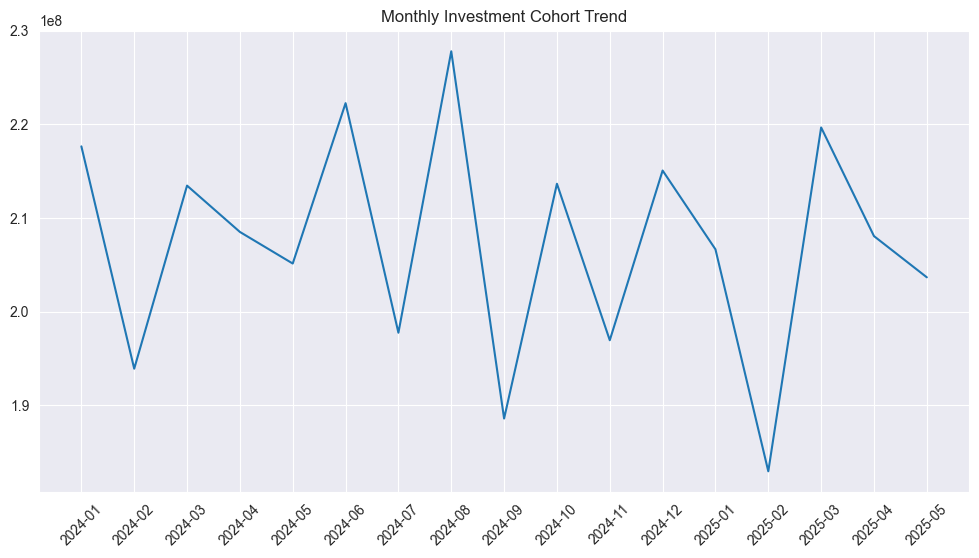

In [3]:
plt.figure(figsize=(12,6))

plt.plot(
    cohort.index.astype(str),
    cohort["investment"]
)

plt.title(
    "Monthly Investment Cohort Trend"
)

plt.xticks(rotation=45)

plt.show()

## Insight

This chart tracks investment activity over time. Cohort analysis helps identify growth trends, seasonal investment behaviour, and investor participation patterns.

In [4]:
ranking_df = performance.copy()

ranking_df["score"] = (
    ranking_df["return_5yr_pct"] * 0.40
    +
    ranking_df["sharpe_ratio"] * 30
    +
    ranking_df["morningstar_rating"] * 5
    -
    ranking_df["expense_ratio_pct"] * 5
)

ranking_df = ranking_df.sort_values(
    "score",
    ascending=False
)

ranking_df[
    [
        "scheme_name",
        "score",
        "return_5yr_pct",
        "sharpe_ratio"
    ]
].head(10)

,scheme_name,score,return_5yr_pct,sharpe_ratio
14,ICICI Pru Liquid Fund - Regular - Growth,254.876,7.94,7.68
23,Kotak Liquid Fund - Regular - Growth,200.704,8.26,6.18
30,ABSL Liquid Fund - Regular - Growth,178.430,7.95,5.14
9,HDFC Short Term Debt Fund - Regular - Growth,69.964,6.41,1.84
4,SBI Magnum Gilt Fund - Regular Plan - Growth,68.922,5.43,1.52
19,Nippon India Gilt Securities Fund - Regular - ...,60.634,8.71,1.33
34,Mirae Asset Large Cap Fund - Regular - Growth,54.572,12.68,1.06
2,SBI Small Cap Fund - Regular Plan - Growth,54.318,20.67,0.94
29,ABSL Small Cap Fund - Regular - Growth,53.870,23.80,0.90
5,HDFC Top 100 Fund - Regular Plan - Growth,53.578,11.32,1.06


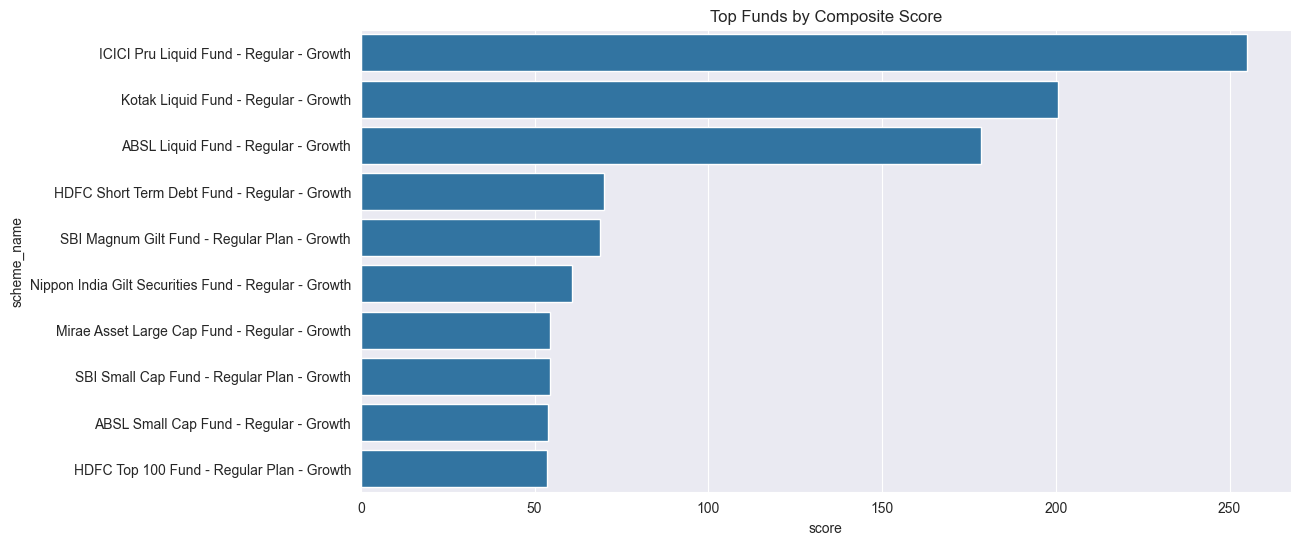

In [5]:
top_score = ranking_df.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_score,
    x="score",
    y="scheme_name"
)

plt.title(
    "Top Funds by Composite Score"
)

plt.show()

## Insight: Portfolio Scoring Model

A composite score was created using return, Sharpe Ratio, Morningstar Rating, and expense ratio. This approach balances performance, risk-adjusted returns, quality ratings, and cost efficiency to identify the most attractive investment opportunities.

In [7]:
ranking_df.to_csv(
    BASE_DIR / "data" / "processed" / "recommended_funds.csv",
    index=False
)

print("Saved successfully")

Saved successfully


# Advanced Analytics Summary

## Objectives

The objective of this analysis was to extend traditional mutual fund analytics using investor cohort analysis, recommendation systems, and portfolio scoring techniques.

## Analyses Performed

### Cohort Analysis
- Analyzed investor participation and investment activity over time.
- Identified monthly investment trends and investor growth patterns.

### Recommendation Engine
- Built a risk-based recommendation framework.
- Generated fund suggestions based on investor risk preferences.

### Portfolio Scoring Model
- Developed a composite score using:
  - 5-Year Return
  - Sharpe Ratio
  - Morningstar Rating
  - Expense Ratio

### Fund Ranking
- Ranked schemes using risk-adjusted and performance-based criteria.
- Identified the most attractive investment opportunities.

## Key Findings

- Investor participation remained relatively stable across cohorts.
- Risk-adjusted metrics significantly improve fund selection quality.
- Composite scoring provides a more balanced evaluation than returns alone.
- Top-ranked funds demonstrated strong returns, favorable Sharpe Ratios, and efficient cost structures.

## Conclusion

Advanced analytics techniques provide deeper investment insights beyond basic performance measures. The recommendation engine and scoring model can support portfolio construction, investor profiling, and future dashboard integrations.